# Classification de CVs — Prédiction de `passed_next_stage`

**Objectif :** prédire si un CV passe à l'étape suivante du recrutement.  
**Priorité métier : maximiser la précision** (éviter les faux positifs).  

**Pipeline :** Chargement → Feature engineering → Preprocessing → LR L1 + seuil F0.5 → Cross-validation → Matrice de confusion → Test sur CVs → Sauvegarde du modèle

## 1. Imports

In [85]:
import warnings

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Chargement & exploration

In [86]:
df = pd.read_csv('../data/cv_dataset.csv')
print(f'Shape : {df.shape}')
print('\nTypes & valeurs manquantes :')
print(pd.concat([df.dtypes.rename('dtype'), df.isnull().sum().rename('nulls')], axis=1))
df.head()

Shape : (500, 21)

Types & valeurs manquantes :
                           dtype  nulls
cv_id                        str      0
age                        int64      0
distance_ville_haute_km  float64      0
target_role                  str      0
total_experience_years   float64      0
total_gap_months           int64      0
nb_gaps                    int64      0
education_degree             str      0
education_field              str      0
education_school             str      0
education_score            int64      0
skills                       str      0
certifications               str      0
number_of_experiences      int64      0
lang_fr                    int64      0
lang_en                    int64      0
lang_de                    int64      0
lang_es                    int64      0
lang_it                    int64      0
lang_other_score_sum       int64      0
passed_next_stage          int64      0


,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1


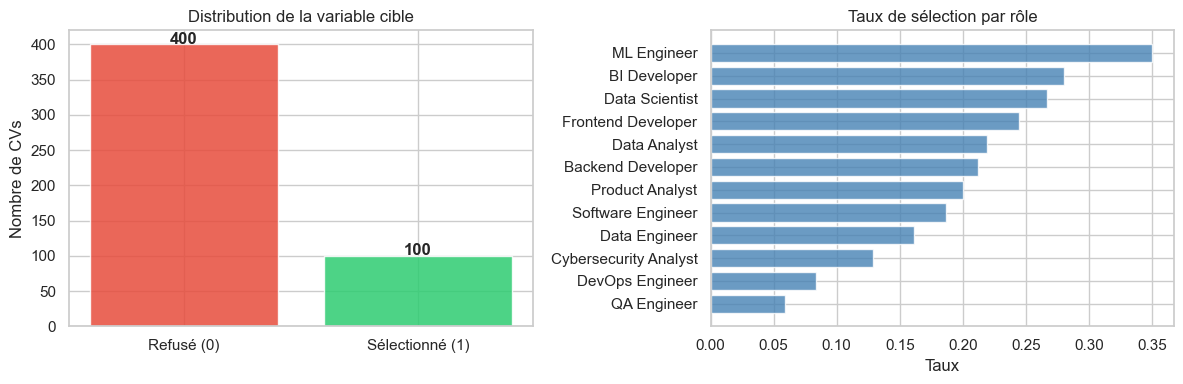

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['passed_next_stage'].value_counts()
axes[0].bar(
    ['Refusé (0)', 'Sélectionné (1)'],
    counts.values,
    color=['#e74c3c', '#2ecc71'],
    alpha=0.85,
    edgecolor='white',
)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de CVs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

role_rate = df.groupby('target_role')['passed_next_stage'].mean().sort_values()
axes[1].barh(role_rate.index, role_rate.values, color='steelblue', alpha=0.8)
axes[1].set_title('Taux de sélection par rôle')
axes[1].set_xlabel('Taux')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [88]:
# Durée moyenne d'un gap (résout la colinéarité nb_gaps / total_gap_months)
df['avg_gap_duration'] = df['total_gap_months'] / (df['nb_gaps'] + 1)

# Part de la carrière passée en gap
df['gap_ratio'] = df['total_gap_months'] / (
        df['total_experience_years'] * 12 + df['total_gap_months'] + 1
)

# Nombre de skills distincts
df['skills_count'] = df['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()])
)

# Nombre de certifications et indicateur binaire
df['certif_count'] = df['certifications'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()])
)
df['has_certif'] = (df['certif_count'] > 0).astype(int)

TARGET = 'passed_next_stage'
DROP_COLS = ['cv_id']

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]
print(f"X : {X.shape}  |  taux positifs : {y.mean():.1%}")

X : (500, 24)  |  taux positifs : 20.0%


## 4. Définition du jeu de colonnes

Plusieurs configurations sont disponibles. Décommenter le bloc souhaité pour changer le jeu actif.

In [89]:
# V1 — complet avec avg_gap_duration (attention au VIF sur nb_gaps)
# NUMERIC_FEATURES = [
#     'age', 'distance_ville_haute_km', 'total_experience_years',
#     'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
#     'skills_count', 'certif_count',
#     'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
# ]
# CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']
# TEXT_SKILLS = 'skills'
# TEXT_CERTIFICATIONS = 'certifications'

# V2 (jeu actif) — sans avg_gap_duration (VIF élevé avec nb_gaps)
# NUMERIC_FEATURES = [
#    'age', 'distance_ville_haute_km', 'total_experience_years',
#    'nb_gaps', 'gap_ratio', 'education_score', 'skills_count',
#    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
# ]
# CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']
# TEXT_SKILLS = 'skills'
# TEXT_CERTIFICATIONS = 'certifications'

# V3 — core uniquement, sans TF-IDF (baseline rapide)
# NUMERIC_FEATURES = [
#     'total_experience_years', 'gap_ratio', 'education_score', 'skills_count',
# ]
# CATEGORICAL_FEATURES = ['target_role', 'education_degree']
# TEXT_SKILLS = None
# TEXT_CERTIFICATIONS = None


# V4 — enrichi avec has_certif et certif_count
NUMERIC_FEATURES = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
    'skills_count', 'certif_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']
TEXT_SKILLS = 'skills'
TEXT_CERTIFICATIONS = 'certifications'

print(
    f"Jeu actif : {len(NUMERIC_FEATURES)} features numériques, "
    f"{len(CATEGORICAL_FEATURES)} catégorielles, "
    f"texte : {TEXT_SKILLS is not None}"
)

Jeu actif : 16 features numériques, 3 catégorielles, texte : True


## 5. Split & Preprocessing

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} obs  |  positifs : {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]} obs   |  positifs : {y_test.mean():.1%}")

X_train, X_test = X_train.copy(), X_test.copy()

# Nettoyage texte (si les colonnes sont actives)
for col in [TEXT_SKILLS, TEXT_CERTIFICATIONS]:
    if col is not None:
        X_train[col] = (
            X_train[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
        )
        X_test[col] = (
            X_test[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
        )

# Construction dynamique du preprocessor selon le jeu actif
transformers = [
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]),
        CATEGORICAL_FEATURES,
    ),
]

if TEXT_SKILLS is not None:
    transformers.append((
        'skills',
        TfidfVectorizer(max_features=50, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
        TEXT_SKILLS,
    ))

if TEXT_CERTIFICATIONS is not None:
    transformers.append((
        'certif',
        TfidfVectorizer(max_features=30, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
        TEXT_CERTIFICATIONS,
    ))


preprocessor = ColumnTransformer(transformers, remainder='drop')
print("Preprocessor défini ✓")

Train : 400 obs  |  positifs : 20.0%
Test  : 100 obs   |  positifs : 20.0%
Preprocessor défini ✓


## 6. Régression Logistique L1 — Cross-Validation

`LogisticRegressionCV` sélectionne automatiquement C par validation croisée interne.  
Une cross-validation externe (5 folds stratifiés) évalue la stabilité des métriques.

In [91]:
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 30),   # grille fine — ton ajout, à garder
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        penalty='l1',
        solver='liblinear',
        scoring='average_precision',
        class_weight=None,
        max_iter=1000,
        random_state=42,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'roc_auc': 'roc_auc',
        'average_precision': 'average_precision',
        'precision': 'precision',
        'f1': 'f1',
    },
    return_train_score=False,
    n_jobs=-1,
)

print("Cross-validation (5 folds) sur le train set :")
for metric, key in [
    ('ROC-AUC', 'test_roc_auc'),
    ('Avg Precision', 'test_average_precision'),
    ('F1', 'test_f1'),
]:
    scores = cv_results[key]
    print(f"  {metric:<18}: {scores.mean():.3f} ± {scores.std():.3f}")

Cross-validation (5 folds) sur le train set :
  ROC-AUC           : 0.770 ± 0.051
  Avg Precision     : 0.449 ± 0.093
  F1                : 0.167 ± 0.125


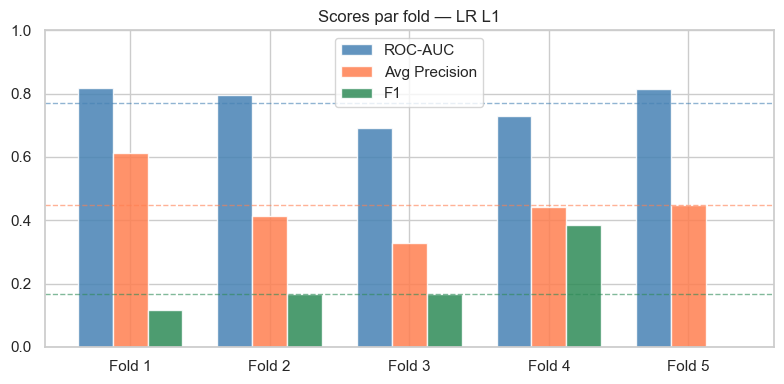

In [92]:
# Visualisation de la stabilité par fold
fig, ax = plt.subplots(figsize=(8, 4))

metrics_to_plot = {
    'ROC-AUC': cv_results['test_roc_auc'],
    'Avg Precision': cv_results['test_average_precision'],
    'F1': cv_results['test_f1'],
}

x = np.arange(5)
width = 0.25
colors = ['steelblue', 'coral', 'seagreen']

for i, (label, scores) in enumerate(metrics_to_plot.items()):
    ax.bar(x + i * width, scores, width, label=label, color=colors[i], alpha=0.85)
    ax.axhline(scores.mean(), color=colors[i], linestyle='--', lw=1, alpha=0.6)

ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i + 1}' for i in range(5)])
ax.set_ylim(0, 1)
ax.set_title('Scores par fold — LR L1')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Entraînement final & seuil F0.5

In [93]:
lr_pipeline.fit(X_train, y_train)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"Meilleur C : {lr_pipeline.named_steps['classifier'].C_[0]:.4f}")

# Reconstruction des noms de features
ohe_names = (
    lr_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
feature_names = NUMERIC_FEATURES + ohe_names

if TEXT_SKILLS is not None:
    skills_names = [
        f"skill_{w}" for w in
        lr_pipeline.named_steps['preprocessor']
        .named_transformers_['skills']
        .get_feature_names_out()
    ]
    feature_names += skills_names

if TEXT_CERTIFICATIONS is not None:
    certif_names = [
        f"certif_{w}" for w in
        lr_pipeline.named_steps['preprocessor']
        .named_transformers_['certif']
        .get_feature_names_out()
    ]
    feature_names += certif_names

coefs = lr_pipeline.named_steps['classifier'].coef_[0]
coef_df = (
    pd.DataFrame({'feature': feature_names, 'coef': coefs, 'abs_coef': np.abs(coefs)})
    .sort_values('abs_coef', ascending=False)
)
print(f"Features retenues (L1) : {(coef_df['abs_coef'] > 0).sum()} / {len(coef_df)}")
print("\nTop 15 features actives :")
print(coef_df[coef_df['abs_coef'] > 0].head(15).to_string(index=False))

Meilleur C : 0.5736
Features retenues (L1) : 23 / 128

Top 15 features actives :
                           feature      coef  abs_coef
education_field_Business Analytics  1.335100  1.335100
            total_experience_years  0.976717  0.976717
 education_degree_Bachelor of Arts -0.567584  0.567584
       target_role_DevOps Engineer -0.517261  0.517261
                   education_score  0.486376  0.486376
          target_role_Data Analyst -0.436838  0.436838
                        certif_aws  0.314713  0.314713
                  certif_certified  0.300289  0.300289
                      certif_count  0.231788  0.231788
                           lang_de  0.226018  0.226018
              lang_other_score_sum  0.217928  0.217928
                           lang_es  0.174447  0.174447
                               age -0.148073  0.148073
           target_role_ML Engineer  0.133716  0.133716
          target_role_BI Developer  0.115390  0.115390


Seuil optimal (F0.5) : 0.292
Précision @ seuil    : 0.448
Recall    @ seuil    : 0.650


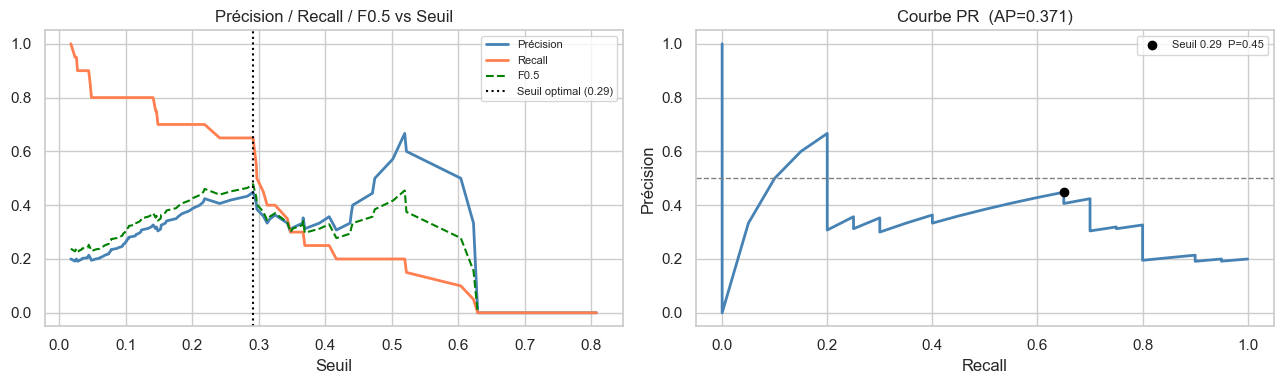

In [94]:
# Optimisation du seuil via F-beta (beta=0.5 pénalise 4x les faux positifs)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
beta = 0.5
fbeta = (1 + beta ** 2) * (precisions * recalls) / (beta ** 2 * precisions + recalls + 1e-9)
best_idx = np.argmax(fbeta[:-1])
best_threshold = thresholds[best_idx]

print(f"Seuil optimal (F0.5) : {best_threshold:.3f}")
print(f"Précision @ seuil    : {precisions[best_idx]:.3f}")
print(f"Recall    @ seuil    : {recalls[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, precisions[:-1], label='Précision', color='steelblue', lw=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', color='coral', lw=2)
axes[0].plot(
    thresholds[:-1], fbeta[:-2], label='F0.5', color='green', lw=1.5, linestyle='--'
)
axes[0].axvline(
    best_threshold, color='black', linestyle=':', lw=1.5,
    label=f'Seuil optimal ({best_threshold:.2f})',
)
axes[0].set_xlabel('Seuil')
axes[0].set_title('Précision / Recall / F0.5 vs Seuil')
axes[0].legend(fontsize=8)

axes[1].plot(recalls, precisions, color='steelblue', lw=2)
axes[1].scatter(
    recalls[best_idx], precisions[best_idx], color='black', zorder=5,
    label=f'Seuil {best_threshold:.2f}  P={precisions[best_idx]:.2f}',
)
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title(f'Courbe PR  (AP={average_precision_score(y_test, y_proba):.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Évaluation finale — Rapport & Matrice de confusion

In [95]:
y_pred = (y_proba >= best_threshold).astype(int)

print(f"=== LR L1 — seuil optimisé {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba):.3f}")

=== LR L1 — seuil optimisé 0.29 ===
              precision    recall  f1-score   support

      Refusé       0.90      0.80      0.85        80
 Sélectionné       0.45      0.65      0.53        20

    accuracy                           0.77       100
   macro avg       0.67      0.73      0.69       100
weighted avg       0.81      0.77      0.78       100

ROC-AUC (test) : 0.683


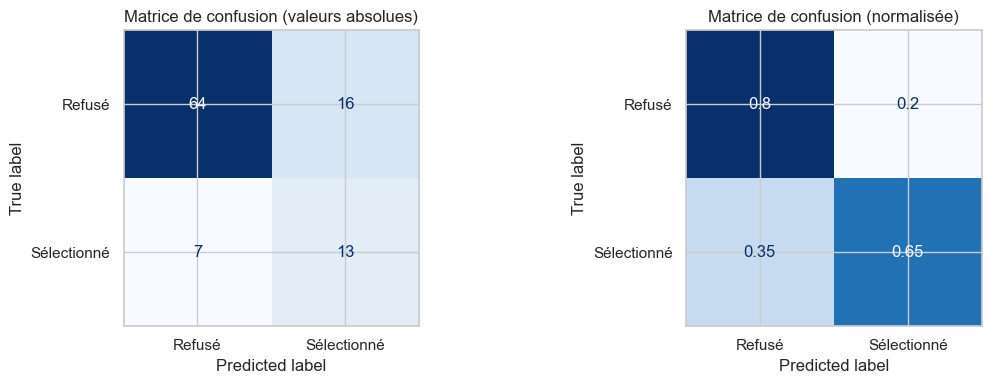

Vrais négatifs  (TN) : 64
Faux positifs   (FP) : 16
Faux négatifs   (FN) : 7
Vrais positifs  (TP) : 13


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice en valeurs absolues
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Refusé', 'Sélectionné']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matrice de confusion (valeurs absolues)')

# Matrice normalisée sur les vrais labels (taux de bonne classification par classe)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Refusé', 'Sélectionné']).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Matrice de confusion (normalisée)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs  (TN) : {tn}")
print(f"Faux positifs   (FP) : {fp}")
print(f"Faux négatifs   (FN) : {fn}")
print(f"Vrais positifs  (TP) : {tp}")

## 9. Prédire un nouveau CV

Exemple d'utilisation du meilleur modèle sur un CV fictif.

In [97]:
# Chargement des nouveaux CVs
new_cv = pd.read_csv("../data/first_json/first_cv_dataset.csv")

# 1. Feature engineering obligatoire avant prédiction
new_cv['avg_gap_duration'] = new_cv['total_gap_months'] / (new_cv['nb_gaps'] + 1)
new_cv['gap_ratio'] = new_cv['total_gap_months'] / (
            new_cv['total_experience_years'] * 12 + new_cv['total_gap_months'] + 1)
new_cv['skills_count'] = new_cv['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()]))
new_cv['certif_count'] = new_cv['certifications'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()]))
new_cv['has_certif'] = (new_cv['certif_count'] > 0).astype(int)

# Nettoyage du texte
for col in ['skills', 'certifications']:
    if col in new_cv.columns:
        new_cv[col] = new_cv[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

# 2. Calcul des probabilités avec le modèle actif du notebook (lr_pipeline)
proba = lr_pipeline.predict_proba(new_cv)[:, 1]
new_cv['proba_selection'] = proba

# 3. Application du seuil optimal dynamique (best_threshold de l'étape 7)
new_cv['prediction'] = np.where(proba >= best_threshold, '✅ Sélectionné', '❌ Refusé')

print(f"Modèle utilisé : Logistic Regression (L1)")
print(f"Seuil appliqué : {best_threshold:.4f}")
print(f"Nombre de CVs évalués : {len(new_cv)}\n")

# 4. Affichage des résultats
colonnes_affichage = ['cv_id', 'target_role', 'prediction', 'proba_selection']
colonnes_affichage = [c for c in colonnes_affichage if c in new_cv.columns]

display(new_cv[colonnes_affichage].head())

Modèle utilisé : Logistic Regression (L1)
Seuil appliqué : 0.2918
Nombre de CVs évalués : 5



,cv_id,target_role,prediction,proba_selection
0,cv1.txt,Senior Data Analyst,✅ Sélectionné,0.713782
1,cv2.txt,Operations Manager,✅ Sélectionné,0.843391
2,cv3.txt,Software Engineering Lead,✅ Sélectionné,0.680175
3,cv4.txt,Financial Controller,✅ Sélectionné,0.906359
4,cv5.txt,Marketing Manager,❌ Refusé,0.263754


## 10. Sauvegarde du modèle

In [98]:
import joblib
import os

# Création du dossier s'il n'existe pas
os.makedirs("../models", exist_ok=True)

chemin_sauvegarde = "../models/model_classification_cv_strict.joblib"

# On sauvegarde la pipeline ET le seuil optimisé dans un dictionnaire
model_data = {
    'pipeline': lr_pipeline,
    'optimal_threshold': best_threshold
}

joblib.dump(model_data, chemin_sauvegarde)

print(f"Modèle et seuil optimisé ({best_threshold:.3f}) sauvegardés avec succès sous : {chemin_sauvegarde}")

Modèle et seuil optimisé (0.292) sauvegardés avec succès sous : ../models/model_classification_cv_strict.joblib
